In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import files

uploaded = files.upload()

Saving seasonal_agriculture_performance_dataset.csv to seasonal_agriculture_performance_dataset (1).csv


In [3]:
df = pd.read_csv("seasonal_agriculture_performance_dataset.csv")

df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [4]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 4000
Columns: 28


In [5]:
df.columns

Index(['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares',
       'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct',
       'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha',
       'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method',
       'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score',
       'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne',
       'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3',
       'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [7]:
df.isnull().sum()

,0
Farm_ID,0
State,0
District,0
Crop,0
Season,0
Farm_Area_Hectares,0
Rainfall_mm,48
Avg_Temperature_C,0
Humidity_pct,0
Sunlight_Hours_Day,0


In [8]:
df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,3952.000000,4000.00000,4000.000000,4000.000000,4000.000000,3960.000000,4000.000000,4000.000000,4000.000000,...,4000.000000,3968.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,601.152657,26.81890,63.210500,7.323050,6.701010,26.508232,120.250825,57.781850,104.760050,...,0.826138,5.270595,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,288.925025,3.81818,11.960834,1.121186,0.641461,6.712484,31.216452,17.015074,27.742681,...,0.101747,13.361398,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,...,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,370.200000,23.90000,54.775000,6.600000,6.260000,21.700000,98.500000,46.200000,86.200000,...,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,582.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,...,0.830000,1.740000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,834.950000,29.60000,71.900000,8.100000,7.140000,31.300000,141.225000,69.400000,123.600000,...,0.910000,2.840000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,...,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000


In [9]:
df["Season"].value_counts()

,count
Season,
Kharif,1779
Rabi,1627
Zaid,594


In [10]:
df.groupby("Season")["Yield_Tonnes_Ha"].mean()

,Yield_Tonnes_Ha
Season,
Kharif,5.643973
Rabi,5.080498
Zaid,4.665942


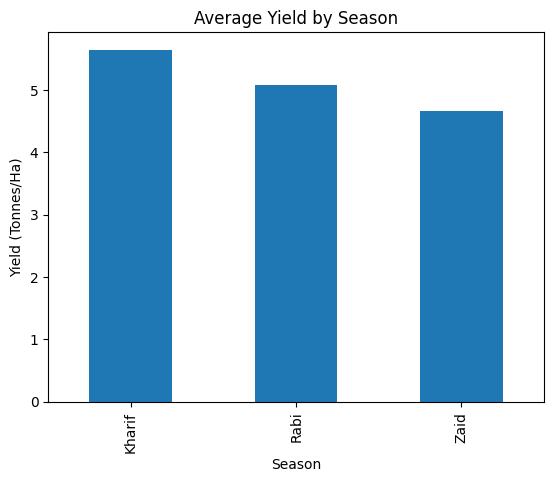

In [11]:
df.groupby("Season")["Yield_Tonnes_Ha"].mean().plot(kind="bar")

plt.title("Average Yield by Season")
plt.xlabel("Season")
plt.ylabel("Yield (Tonnes/Ha)")
plt.show()

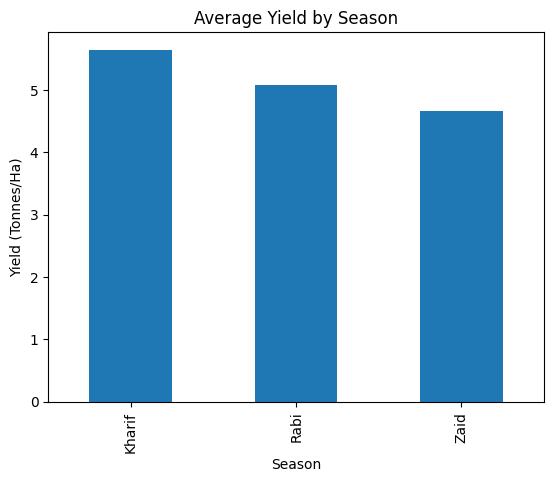

In [12]:
df.groupby("Season")["Yield_Tonnes_Ha"].mean().plot(kind="bar")

plt.title("Average Yield by Season")
plt.xlabel("Season")
plt.ylabel("Yield (Tonnes/Ha)")
plt.show()

In [13]:
df.groupby("Season")["Profit_INR"].mean()

,Profit_INR
Season,
Kharif,178914.647555
Rabi,87689.470191
Zaid,-24804.824916


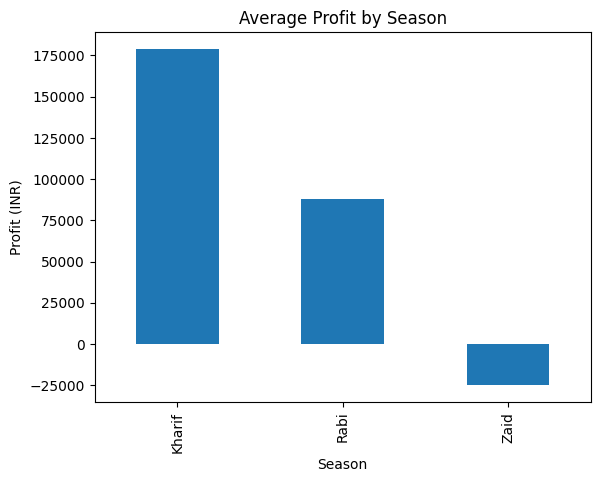

In [14]:
df.groupby("Season")["Profit_INR"].mean().plot(kind="bar")

plt.title("Average Profit by Season")
plt.xlabel("Season")
plt.ylabel("Profit (INR)")
plt.show()

In [15]:
df.groupby("Season")["Water_Used_m3"].mean()

,Water_Used_m3
Season,
Kharif,6102.201237
Rabi,5846.987093
Zaid,6419.893939


In [16]:
df.groupby("Season")["Fertilizer_kg_ha"].mean()

,Fertilizer_kg_ha
Season,
Kharif,187.077965
Rabi,185.407068
Zaid,184.638047


In [17]:
df.groupby("Season")["Water_Efficiency_t_per_1000m3"].mean()

,Water_Efficiency_t_per_1000m3
Season,
Kharif,5.891834
Rabi,5.186122
Zaid,4.413239


In [18]:
df.groupby("Season")["Rainfall_mm"].mean()

,Rainfall_mm
Season,
Kharif,852.084205
Rabi,436.000124
Zaid,299.421784


In [19]:
df.groupby("Season")["Avg_Temperature_C"].mean()

,Avg_Temperature_C
Season,
Kharif,28.454019
Rabi,23.489183
Zaid,31.042088


In [20]:
df.groupby("Season")["Soil_Moisture_pct"].mean()

,Soil_Moisture_pct
Season,
Kharif,31.198410
Rabi,24.050620
Zaid,19.170085


In [21]:
df.groupby("Season")["Disease_Pest_Risk_pct"].mean()

,Disease_Pest_Risk_pct
Season,
Kharif,54.467903
Rabi,40.482114
Zaid,38.216667


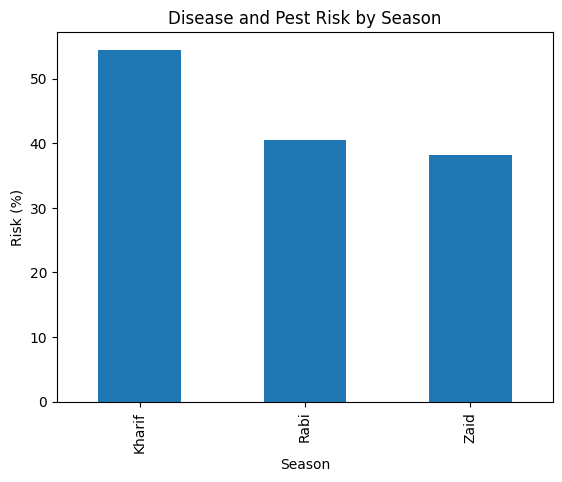

In [22]:
df.groupby("Season")["Disease_Pest_Risk_pct"].mean().plot(kind="bar")

plt.title("Disease and Pest Risk by Season")
plt.xlabel("Season")
plt.ylabel("Risk (%)")
plt.show()

In [23]:
#crop wise analysis
df.groupby("Crop")["Yield_Tonnes_Ha"].mean().sort_values(ascending=False)

,Yield_Tonnes_Ha
Crop,
Sugarcane,46.938746
Maize,2.717130
Rice,2.439413
Wheat,2.109216
Chilli,1.540344
Groundnut,1.317924
Cotton,1.225734
Pulses,0.918198


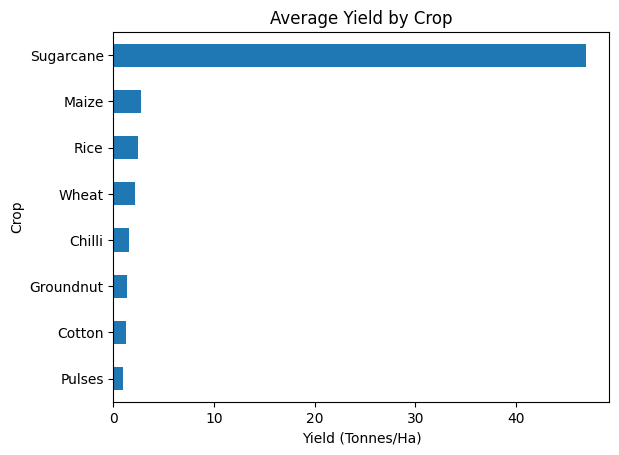

In [24]:
df.groupby("Crop")["Yield_Tonnes_Ha"].mean().sort_values().plot(kind="barh")

plt.title("Average Yield by Crop")
plt.xlabel("Yield (Tonnes/Ha)")
plt.show()

In [25]:
df.groupby("Crop")["Profit_INR"].mean().sort_values(ascending=False)

,Profit_INR
Crop,
Sugarcane,817187.986885
Chilli,750878.342233
Cotton,124546.915354
Groundnut,44858.120283
Pulses,-4238.052419
Maize,-83978.326679
Rice,-102213.504348
Wheat,-123398.337134


In [26]:
#irrigation analysis
df.groupby("Irrigation_Method")["Yield_Tonnes_Ha"].mean().sort_values(ascending=False)

,Yield_Tonnes_Ha
Irrigation_Method,
Drip,6.620662
Sprinkler,5.188819
Flood,4.897724
Rainfed,4.613182


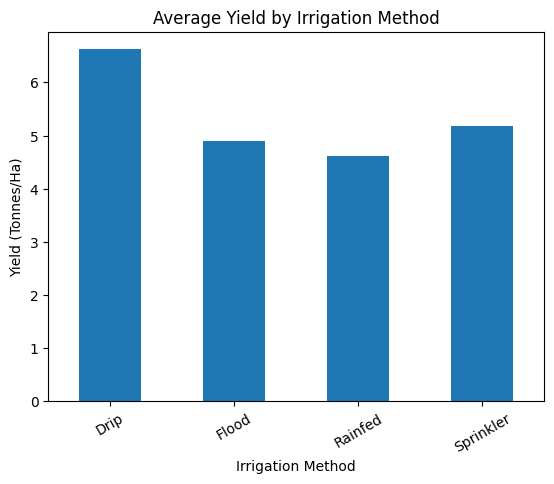

In [27]:
df.groupby("Irrigation_Method")["Yield_Tonnes_Ha"].mean().plot(kind="bar")

plt.title("Average Yield by Irrigation Method")
plt.xlabel("Irrigation Method")
plt.ylabel("Yield (Tonnes/Ha)")
plt.xticks(rotation=30)
plt.show()

In [28]:
df.groupby("Irrigation_Method")["Water_Efficiency_t_per_1000m3"].mean().sort_values(ascending=False)

,Water_Efficiency_t_per_1000m3
Irrigation_Method,
Rainfed,7.563784
Drip,6.267129
Sprinkler,4.669805
Flood,3.438853


In [29]:
#RELATIONSHIPS BETWEEN VARIABLES
df.corr(numeric_only=True)["Yield_Tonnes_Ha"].sort_values(ascending=False)

,Yield_Tonnes_Ha
Yield_Tonnes_Ha,1.000000
Water_Efficiency_t_per_1000m3,0.915438
Production_Tonnes,0.885171
Profit_INR,0.489822
Revenue_INR,0.433648
Water_Used_m3,0.388653
Nitrogen_kg_ha,0.053867
Phosphorus_kg_ha,0.047821
Rainfall_mm,0.030853
Total_Cost_INR,0.030814


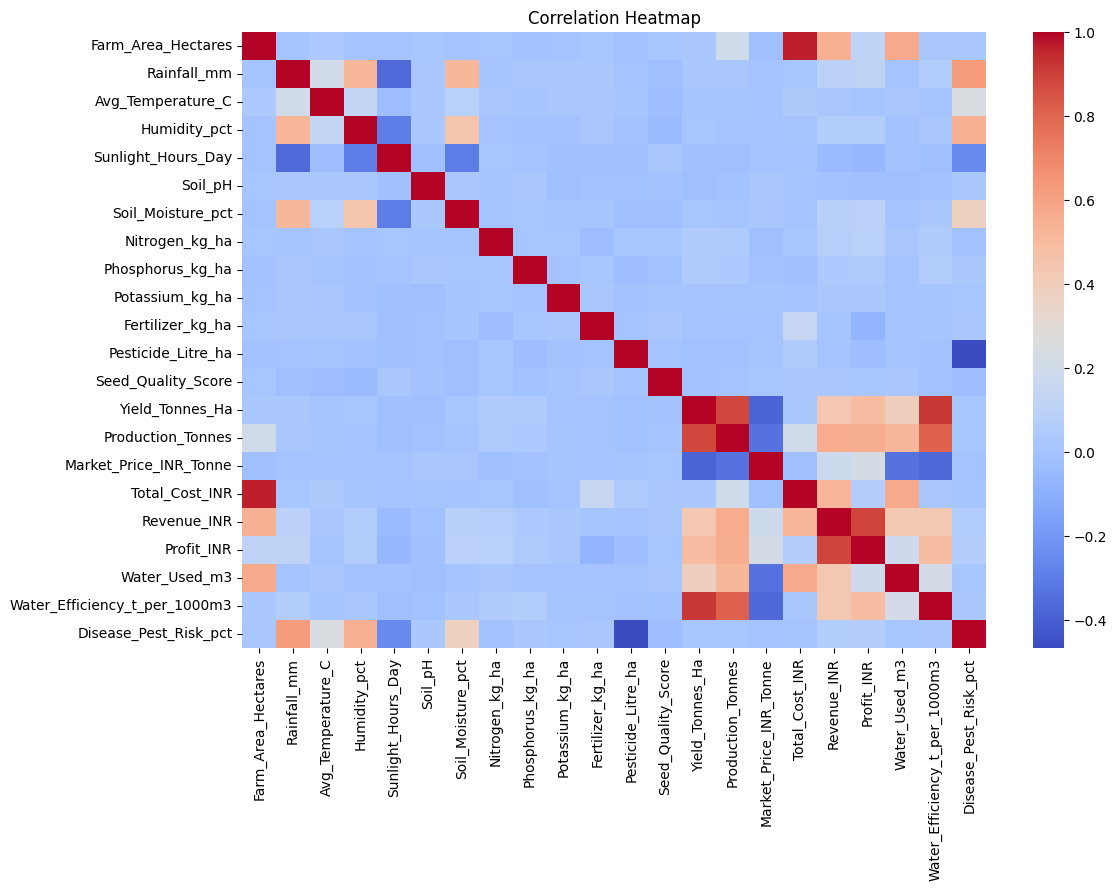

In [30]:
corr = df.select_dtypes("number").corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

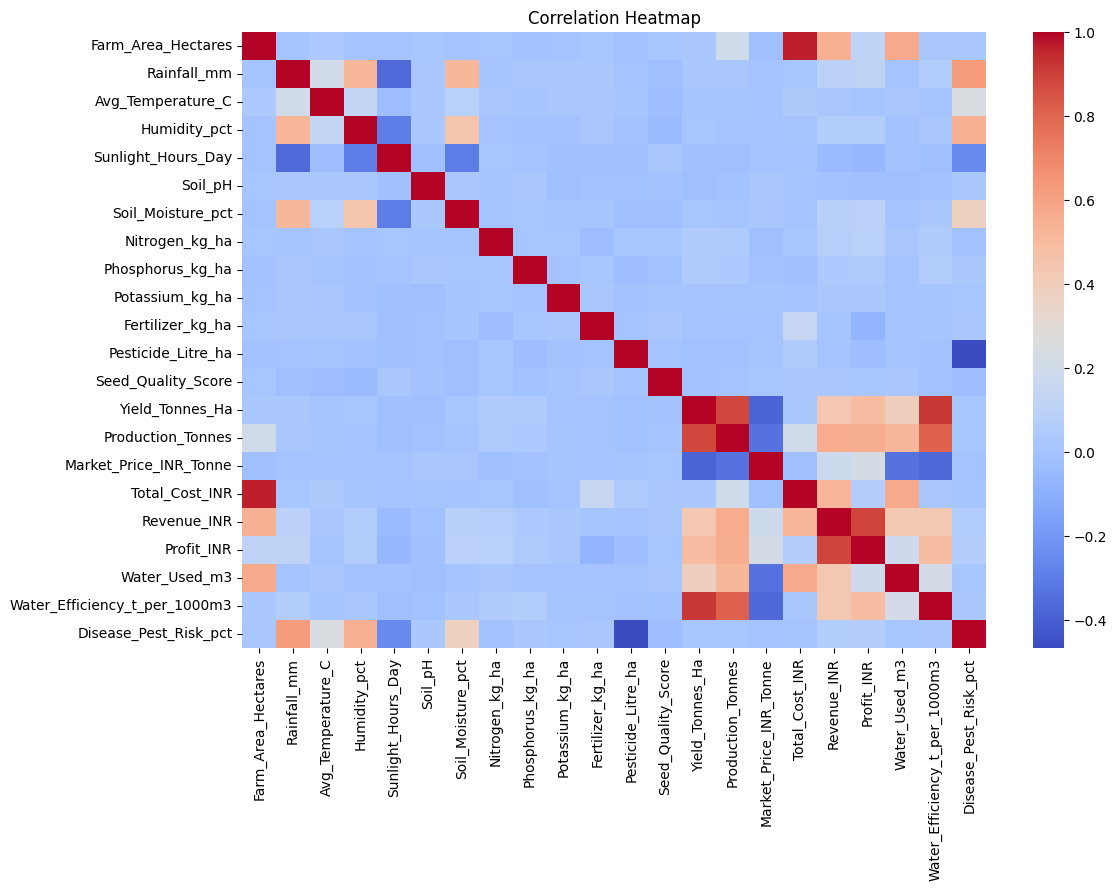

In [31]:
corr = df.select_dtypes("number").corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

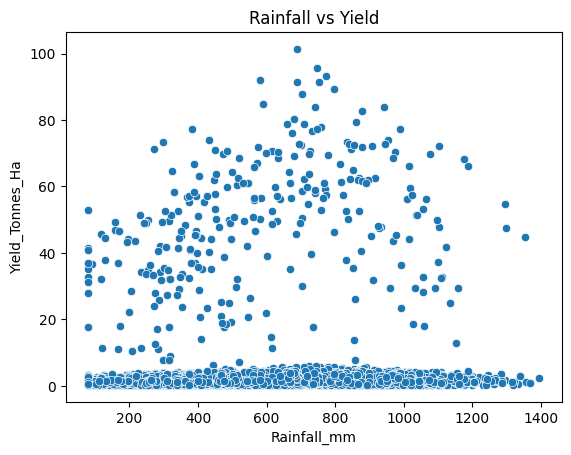

In [32]:
sns.scatterplot(data=df, x="Rainfall_mm", y="Yield_Tonnes_Ha")

plt.title("Rainfall vs Yield")
plt.show()

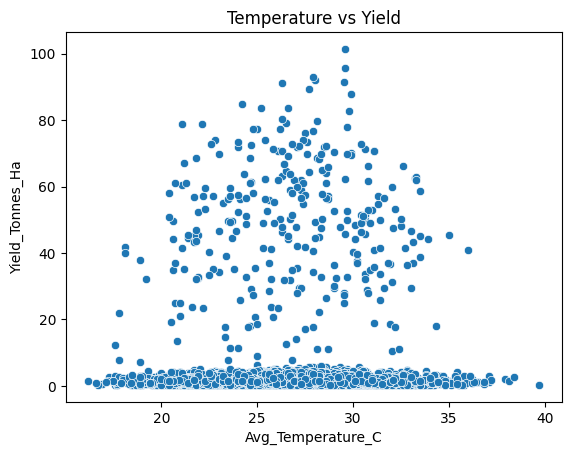

In [33]:
sns.scatterplot(data=df, x="Avg_Temperature_C", y="Yield_Tonnes_Ha")

plt.title("Temperature vs Yield")
plt.show()

In [34]:
# STATE-WISE ANALYSIS
df.groupby("State")["Yield_Tonnes_Ha"].mean().sort_values(ascending=False)

,Yield_Tonnes_Ha
State,
Punjab,6.121116
Karnataka,5.734493
Gujarat,5.699586
Telangana,5.076810
Maharashtra,5.030333
Madhya Pradesh,5.029654
Tamil Nadu,4.901247
Andhra Pradesh,4.650781


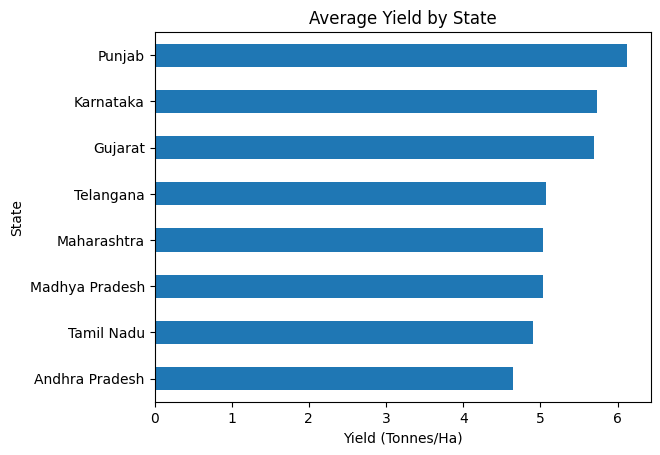

In [35]:
df.groupby("State")["Yield_Tonnes_Ha"].mean().sort_values().plot(kind="barh")

plt.title("Average Yield by State")
plt.xlabel("Yield (Tonnes/Ha)")
plt.show()

In [36]:
summary = df.groupby("Season").agg({
    "Yield_Tonnes_Ha": "mean",
    "Production_Tonnes": "mean",
    "Profit_INR": "mean",
    "Water_Used_m3": "mean",
    "Water_Efficiency_t_per_1000m3": "mean",
    "Disease_Pest_Risk_pct": "mean"
})

summary

,Yield_Tonnes_Ha,Production_Tonnes,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
Season,,,,,,
Kharif,5.643973,46.311192,178914.647555,6102.201237,5.891834,54.467903
Rabi,5.080498,41.486712,87689.470191,5846.987093,5.186122,40.482114
Zaid,4.665942,38.886111,-24804.824916,6419.893939,4.413239,38.216667


In [38]:
best_season = summary["Yield_Tonnes_Ha"].idxmax()

print("Best season based on average yield:", best_season)

Best season based on average yield: Kharif
